<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/El_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El Perceptrón: La neurona que inició la inteligencia artificial
##  Cómo una simple fórmula matemática aprendió a tomar decisiones

## Índice

### **Sección 1: Introducción - El sueño de imitar al cerebro**
- Contexto histórico: Frank Rosenblatt y el Mark I(1957)
- Analogía biológica: neurona vs. perceptrón
- Objetivo: crear máquinas que aprendan de datos

### **Sección 2: Anatomía del Perceptrón**
- Componentes fundamentales:
  - Las entradas ($x_1, x_2, ... x_n$): los datos de entrada
  - Los pesos sinápticos ($w_1, w_2, ... w_n$): la "importancia" de cada entrada
  - El *bias* ($b$): el umbral de decisión
  - La función de activación escalón: la decisión binaria
- La fórmula esencial: $y = f(\sum w_i x_i + b)$
- Tu primer perceptrón en código (bloque práctico)
- Demostración visual: rectas que separan el espacio

### **Sección 3: Aprendiendo de los ejemplos**
- Regla de aprendizaje del Perceptrón (explicación intuitiva)
- Aplicación práctica:
  - Compuerta AND: separable linealmente
  - Compuerta OR: separable linealmente
- Visualización de rectas separadoras en el plano 2D

### **Sección 4: El problema del XOR  y la revolución de las capas**
- XOR: el problema que una sola neurona no puede resolver.
- Demostración geométrica: por qué no existe una recta separadora.
- Solución: múltiples perceptrones trabajando juntos.
- Arquitectura de dos capas para resolver XOR.
- De rectas a regiones poligonales: el poder de la composición.
- El nacimiento conceptual del perceptrón multicapa (MLP).

### **Sección 5: Conclusiones**
- El perceptrón es elegante en su simplicidad pero limitado en soledad
- La potencia surge de la conexión entre unidades simples
- Puente histórico entre la lógica booleana y el aprendizaje profundo
- Principio fundamental: a veces la complejidad emerge de lo simple

#### Mensaje final
Lo que no puede hacer una neurona artificial, lo pueden hacer varias trabajando juntas, igual que en nuestro cerebro.

## Sección 1: Introducción - El sueño de imitar al cerebro

En 1957, el psicólogo Frank Rosenblatt presentó el **Mark I Perceptron**, una máquina del tamaño de una habitación diseñada para reconocer patrones visuales simples. No era un ordenador programado con reglas, sino algo revolucionario: una máquina que **aprendía de ejemplos**.

### La inspiración biológica

Para entender el perceptrón, primero debemos mirar al cerebro humano. Nuestro cerebro contiene aproximadamente 86 mil millones de neuronas, células especializadas que se comunican entre sí formando redes inmensamente complejas. Cada neurona es, en esencia, un procesador simple:

<img src="https://github.com/financieras/math_for_ai/blob/main/img/neuron.png?raw=1" alt="neuron structure" width="480"/>

1. **Recibe información**: A través de sus dendritas, recibe impulsos eléctricos de cientos o miles de otras neuronas.
2. **Evalúa las entradas**: Integra todas estas señales, algunas excitatorias (que impulsan la activación) y otras inhibitorias (que la frenan).
3. **Toma una decisión**: Si la suma de todas estas señales supera cierto umbral, la neurona se activa y envía su propio impulso eléctrico a través del axón.
4. **Transmite a otras neuronas**: Esta señal viaja a través de las sinapsis hacia las neuronas conectadas, propagando información.

Esta estructura tan simple, **repetida miles de millones de veces y organizada en capas y circuitos**, da lugar a fenómenos extraordinarios: pensamientos, recuerdos, emociones y nuestra capacidad de aprender del mundo que nos rodea. Una sola neurona es limitada, pero billones trabajando en conjunto producen la inteligencia.

### Del cerebro a la máquina

La idea de Rosenblatt era elegante: ¿podríamos capturar esta lógica fundamental en una ecuación matemática? El perceptrón artificial replica este proceso neuronal básico:

- Recibe **entradas numéricas** $x_1, x_2, ..., x_n$ (como las señales que llegan por las dendritas)
- Cada entrada tiene un **peso** $w_1, w_2, ..., w_n$ que determina su importancia (simulando la fuerza de las conexiones sinápticas)
- Si la suma ponderada supera un **umbral** (el bias $b$), la neurona artificial se activa
- Con cada error en sus predicciones, **ajusta sus pesos automáticamente** para mejorar

**El objetivo**: crear máquinas capaces de aprender automáticamente a clasificar, decidir y reconocer patrones sin que un humano les programe cada regla explícitamente. En lugar de decirle a la máquina "si ves esto, haz aquello", le mostramos ejemplos y ella descubre las reglas por sí misma.

Lo fascinante es que este modelo simple, inspirado directamente en la biología, sentó las bases de lo que décadas después se convertiría en el aprendizaje profundo. El perceptrón nos enseñó una lección fundamental: **la complejidad puede emerger de unidades simples trabajando juntas**.

Comencemos explorando cómo funciona esta neurona artificial.

## Sección 2: Anatomía del Perceptrón

Un perceptrón es sorprendentemente simple. Podemos descomponerlo en cuatro elementos fundamentales que trabajan en secuencia:

<img src="https://github.com/financieras/math_for_ai/blob/main/img/perceptron.webp?raw=1" alt="perceptron" width="480"/>


### Componentes fundamentales

**1. Las entradas ($x_1, x_2, ..., x_n$): los datos de entrada**

Son los valores numéricos que alimentan al perceptrón. Por ejemplo, si queremos clasificar si un email es spam:
- $x_1$ podría ser el número de palabras "gratis"
- $x_2$ podría ser el número de signos de exclamación
- $x_3$ podría ser si contiene enlaces sospechosos (0 o 1)

**2. Los pesos sinápticos ($w_1, w_2, ..., w_n$): la "importancia" de cada entrada**

Cada entrada tiene asociado un peso que indica cuánto influye en la decisión final. Un peso grande (positivo o negativo) significa que esa entrada es muy importante; un peso cercano a cero significa que es casi irrelevante.

Por ejemplo: $w_1 = 2.5$ significa que la palabra "gratis" tiene mucho peso en identificar spam, mientras que $w_3 = 0.1$ significa que los enlaces tienen poca influencia.

Estos pesos son los **parámetros que el perceptrón aprende** ajustándolos con cada ejemplo.

**3. El bias ($b$): el umbral de decisión**

El bias desplaza el umbral de activación. Sin él, la decisión siempre pasaría por el origen (0,0). Con el bias, podemos mover la frontera de decisión a donde necesitemos.

Piénsalo así: incluso si todas las entradas son cero, el bias puede hacer que el perceptrón se active o no.

**4. La función de activación escalón: la decisión binaria**

Una vez calculada la suma ponderada, necesitamos una decisión: ¿se activa o no? La función escalón es binaria:

$$
f(z) = \begin{cases}
1 & \text{si } z \geq 0 \\
0 & \text{si } z < 0
\end{cases}
$$

Si la suma ponderada es positiva o cero, devuelve 1 (activado). Si es negativa, devuelve 0 (no activado).

### La fórmula esencial

Todo el proceso del perceptrón se resume en una ecuación elegante:

$$
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
$$

O escrito paso a paso:
1. Multiplicamos cada entrada por su peso: $w_1 x_1 + w_2 x_2 + ... + w_n x_n$
2. Sumamos el bias: $w_1 x_1 + w_2 x_2 + ... + w_n x_n + b$
3. Aplicamos la función escalón al resultado para obtener 0 o 1

### Tu primer perceptrón en código

Veamos cómo implementar un perceptrón simple en Python:

In [1]:
import numpy as np

class Perceptron:
    def __init__(self, n_inputs):
        """
        Initialize a perceptron with random weights and bias.

        Args:
            n_inputs: Number of input features
        """
        self.weights = np.random.randn(n_inputs)
        self.bias = np.random.randn()

    def activation(self, z):
        """
        Step activation function.

        Args:
            z: Weighted sum of inputs

        Returns:
            1 if z >= 0, else 0
        """
        return 1 if z >= 0 else 0

    def predict(self, x):
        """
        Make a prediction for input x.

        Args:
            x: Input array

        Returns:
            Predicted class (0 or 1)
        """
        # Calculate weighted sum
        z = np.dot(self.weights, x) + self.bias
        # Apply activation function
        return self.activation(z)

# Example: perceptron with 2 inputs
perceptron = Perceptron(n_inputs=2)

# Test with a point
point = np.array([1.5, 2.0])
prediction = perceptron.predict(point)
print(f"Prediction for {point}: {prediction}")

Prediction for [1.5 2. ]: 1


### Demostración visual: rectas que separan el espacio

Aquí está la interpretación geométrica clave: **un perceptrón con dos entradas dibuja una línea recta en el plano** que divide el espacio en dos regiones:

- Todos los puntos en un lado de la recta son clasificados como 0
- Todos los puntos en el otro lado son clasificados como 1

La ecuación de esta recta viene directamente de la condición del umbral:
$$w_1 x_1 + w_2 x_2 + b = 0$$

Veamos un ejemplo visual:

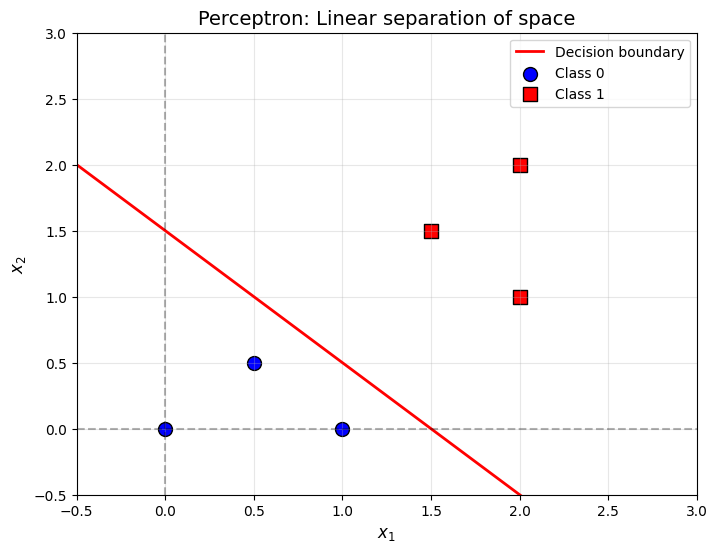

In [2]:
import matplotlib.pyplot as plt

# Create a perceptron with specific weights
weights = np.array([1, 1])
bias = -1.5

# Generate test points
x1 = np.linspace(-1, 3, 100)
x2 = -(weights[0] * x1 + bias) / weights[1]  # Solve for x2

# Visualize
plt.figure(figsize=(8, 6))
plt.plot(x1, x2, 'r-', linewidth=2, label='Decision boundary')
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.axvline(0, color='k', linestyle='--', alpha=0.3)

# Add some example points
class_0_points = np.array([[0, 0], [0.5, 0.5], [1, 0]])
class_1_points = np.array([[2, 2], [1.5, 1.5], [2, 1]])

plt.scatter(class_0_points[:, 0], class_0_points[:, 1],
           c='blue', s=100, marker='o', label='Class 0', edgecolors='k')
plt.scatter(class_1_points[:, 0], class_1_points[:, 1],
           c='red', s=100, marker='s', label='Class 1', edgecolors='k')

plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Perceptron: Linear separation of space', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 3)
plt.ylim(-0.5, 3)
plt.show()

**Observación crucial**: El perceptrón solo puede resolver problemas **linealmente separables**, es decir, aquellos donde podemos trazar una línea recta (o un hiperplano en dimensiones superiores) que separe perfectamente las dos clases.

En la siguiente sección veremos cómo entrenar este perceptrón para que aprenda automáticamente los pesos correctos.

## Sección 3: Aprendiendo de los ejemplos

Hasta ahora hemos visto la estructura del perceptrón, pero ¿cómo aprende? La belleza del perceptrón está en su **regla de aprendizaje**: un algoritmo simple que ajusta los pesos automáticamente basándose en sus errores.

### Regla de aprendizaje del Perceptrón (explicación intuitiva)

El proceso es sorprendentemente directo:

1. **Inicialización**: Comenzamos con pesos aleatorios
2. **Predicción**: Para cada ejemplo de entrenamiento, hacemos una predicción
3. **Comparación**: Comparamos la predicción con la respuesta correcta
4. **Ajuste**: Si nos equivocamos, ajustamos los pesos en la dirección correcta
5. **Repetición**: Repetimos hasta que clasifiquemos todos los ejemplos correctamente (o alcancemos un número máximo de iteraciones)

La regla matemática de actualización es:

$$
w_i \leftarrow w_i + \alpha \cdot (y - \hat{y}) \cdot x_i
$$

$$
b \leftarrow b + \alpha \cdot (y - \hat{y})
$$

Donde:
- $\alpha$ es la **tasa de aprendizaje** (un número pequeño, típicamente 0.01 - 0.1)
- $(y - \hat{y})$ es el **error**
- $y$ es la etiqueta real
- $\hat{y}$ es la predicción del perceptrón

**Intuición**:
- Si predecimos 0 pero debería ser 1: el error es +1, así que **incrementamos** los pesos
- Si predecimos 1 pero debería ser 0: el error es -1, así que **decrementamos** los pesos
- Si acertamos: el error es 0, no cambiamos nada

Implementemos esto en código:

In [3]:
import numpy as np

class PerceptronWithLearning:
    def __init__(self, n_inputs, learning_rate=0.1):
        """
        Initialize perceptron with learning capability.

        Args:
            n_inputs: Number of input features
            learning_rate: Step size for weight updates (alpha)
        """
        self.weights = np.random.randn(n_inputs)
        self.bias = np.random.randn()
        self.learning_rate = learning_rate

    def activation(self, z):
        """Step activation function."""
        return 1 if z >= 0 else 0

    def predict(self, x):
        """Make a prediction."""
        z = np.dot(self.weights, x) + self.bias
        return self.activation(z)

    def train(self, X, y, epochs=100):
        """
        Train the perceptron on dataset.

        Args:
            X: Training inputs (n_samples, n_features)
            y: True labels (n_samples,)
            epochs: Number of training iterations

        Returns:
            List of errors per epoch
        """
        errors_per_epoch = []

        for epoch in range(epochs):
            total_error = 0

            for xi, y_true in zip(X, y):
                # Make prediction
                y_pred = self.predict(xi)

                # Calculate error
                error = y_true - y_pred

                # Update weights and bias
                self.weights += self.learning_rate * error * xi
                self.bias += self.learning_rate * error

                # Track total error
                total_error += abs(error)

            errors_per_epoch.append(total_error)

            # Stop if perfect classification
            if total_error == 0:
                print(f"Converged in {epoch + 1} epochs")
                break

        return errors_per_epoch

### Aplicación práctica: Compuertas lógicas

Las compuertas lógicas son el ejemplo perfecto para demostrar el aprendizaje del perceptrón. Son problemas simples con patrones claros que podemos visualizar fácilmente.

#### Compuerta AND: separable linealmente

La compuerta AND devuelve 1 solo cuando **ambas** entradas son 1:

| $x_1$ | $x_2$ | AND |
|-------|-------|-----|
| 0     | 0     | 0   |
| 0     | 1     | 0   |
| 1     | 0     | 0   |
| 1     | 1     | 1   |

Entrenemos un perceptrón para aprender esta función:

In [4]:
# Training data for AND gate
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_and = np.array([0, 0, 0, 1])

# Create and train perceptron
perceptron_and = PerceptronWithLearning(n_inputs=2, learning_rate=0.1)
errors_and = perceptron_and.train(X_and, y_and, epochs=100)

# Test the trained perceptron
print("\nAND Gate - Predictions:")
for x, y_true in zip(X_and, y_and):
    y_pred = perceptron_and.predict(x)
    print(f"Input: {x} | True: {y_true} | Predicted: {y_pred}")

print(f"\nLearned weights: {perceptron_and.weights}")
print(f"Learned bias: {perceptron_and.bias:.3f}")

Converged in 12 epochs

AND Gate - Predictions:
Input: [0 0] | True: 0 | Predicted: 0
Input: [0 1] | True: 0 | Predicted: 0
Input: [1 0] | True: 0 | Predicted: 0
Input: [1 1] | True: 1 | Predicted: 1

Learned weights: [0.0636256  0.11165771]
Learned bias: -0.127


#### Compuerta OR: separable linealmente

La compuerta OR devuelve 1 cuando **al menos una** entrada es 1:

| $x_1$ | $x_2$ | OR |
|-------|-------|-----|
| 0     | 0     | 0   |
| 0     | 1     | 1   |
| 1     | 0     | 1   |
| 1     | 1     | 1   |

In [5]:
# Training data for OR gate
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_or = np.array([0, 1, 1, 1])

# Create and train perceptron
perceptron_or = PerceptronWithLearning(n_inputs=2, learning_rate=0.1)
errors_or = perceptron_or.train(X_or, y_or, epochs=100)

# Test the trained perceptron
print("\nOR Gate - Predictions:")
for x, y_true in zip(X_or, y_or):
    y_pred = perceptron_or.predict(x)
    print(f"Input: {x} | True: {y_true} | Predicted: {y_pred}")

Converged in 20 epochs

OR Gate - Predictions:
Input: [0 0] | True: 0 | Predicted: 0
Input: [0 1] | True: 1 | Predicted: 1
Input: [1 0] | True: 1 | Predicted: 1
Input: [1 1] | True: 1 | Predicted: 1


### Visualización de rectas separadoras en el plano 2D

Visualicemos cómo el perceptrón ha aprendido a separar los datos:

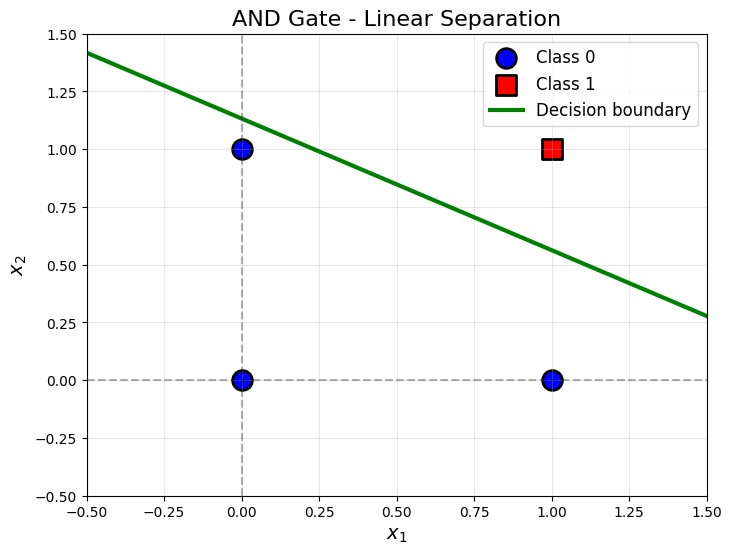

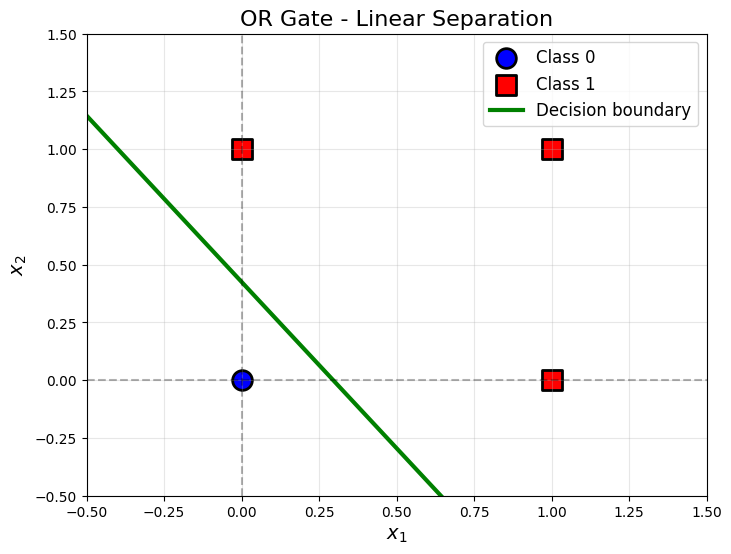

In [6]:
import matplotlib.pyplot as plt

def plot_decision_boundary(perceptron, X, y, title):
    """
    Plot the decision boundary learned by the perceptron.

    Args:
        perceptron: Trained perceptron
        X: Input data
        y: True labels
        title: Plot title
    """
    plt.figure(figsize=(8, 6))

    # Plot data points
    for i, label in enumerate([0, 1]):
        mask = y == label
        marker = 'o' if label == 0 else 's'
        color = 'blue' if label == 0 else 'red'
        plt.scatter(X[mask, 0], X[mask, 1],
                   c=color, s=200, marker=marker,
                   label=f'Class {label}', edgecolors='k', linewidth=2)

    # Plot decision boundary
    x1_vals = np.linspace(-0.5, 1.5, 100)
    # Solve for x2: w1*x1 + w2*x2 + b = 0
    if perceptron.weights[1] != 0:
        x2_vals = -(perceptron.weights[0] * x1_vals + perceptron.bias) / perceptron.weights[1]
        plt.plot(x1_vals, x2_vals, 'g-', linewidth=3, label='Decision boundary')

    plt.xlabel('$x_1$', fontsize=14)
    plt.ylabel('$x_2$', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(0, color='k', linestyle='--', alpha=0.3)

    plt.show()

# Visualize both gates
plot_decision_boundary(perceptron_and, X_and, y_and, 'AND Gate - Linear Separation')
plot_decision_boundary(perceptron_or, X_or, y_or, 'OR Gate - Linear Separation')

**Observación importante**: En ambos casos (AND y OR), el perceptrón encuentra una línea recta que separa perfectamente la clase 0 de la clase 1. Esto confirma que ambos problemas son **linealmente separables**.

Pero... ¿qué sucede cuando un problema NO es linealmente separable? Esa es precisamente la pregunta que exploraremos en la siguiente sección con el famoso **problema del XOR**.

## Sección 4: El problema del XOR y la revolución de las capas

Acabamos de ver que el perceptrón puede aprender las compuertas AND y OR sin problemas. Ahora probemos con otra compuerta lógica aparentemente simple: el **XOR** (OR exclusivo).

### XOR: el problema que una sola neurona no puede resolver

La compuerta XOR devuelve 1 cuando las entradas son **diferentes**:

| $x_1$ | $x_2$ | XOR |
|-------|-------|-----|
| 0     | 0     | 0   |
| 0     | 1     | 1   |
| 1     | 0     | 1   |
| 1     | 1     | 0   |

Intentemos entrenar un perceptrón para resolver XOR:



XOR Gate - Predictions:
Input: [0 0] | True: 0 | Predicted: 1 ✗
Input: [0 1] | True: 1 | Predicted: 1 ✓
Input: [1 0] | True: 1 | Predicted: 0 ✗
Input: [1 1] | True: 0 | Predicted: 0 ✓


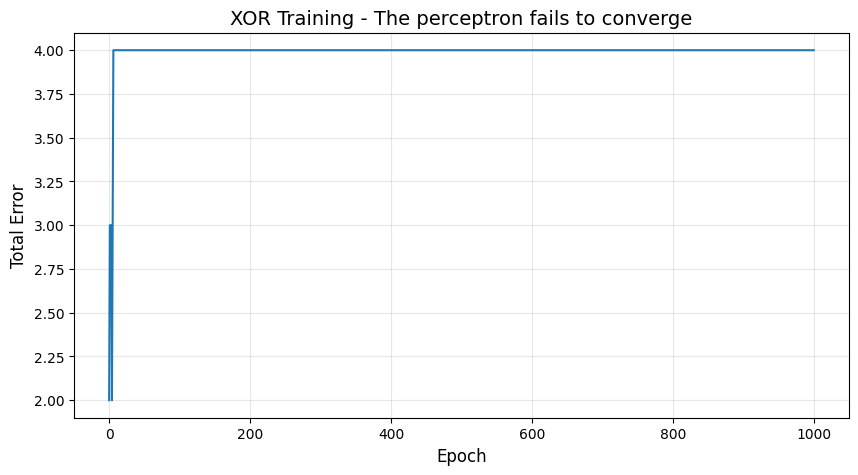

In [7]:
# Training data for XOR gate
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_xor = np.array([0, 1, 1, 0])

# Create and train perceptron
perceptron_xor = PerceptronWithLearning(n_inputs=2, learning_rate=0.1)
errors_xor = perceptron_xor.train(X_xor, y_xor, epochs=1000)

# Test the trained perceptron
print("\nXOR Gate - Predictions:")
for x, y_true in zip(X_xor, y_xor):
    y_pred = perceptron_xor.predict(x)
    status = "✓" if y_pred == y_true else "✗"
    print(f"Input: {x} | True: {y_true} | Predicted: {y_pred} {status}")

# Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(errors_xor)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Total Error', fontsize=12)
plt.title('XOR Training - The perceptron fails to converge', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

**Resultado**: El perceptrón no converge. El error oscila sin llegar nunca a cero. ¿Por qué?

### Demostración geométrica: por qué no existe una recta separadora

Visualicemos el problema:

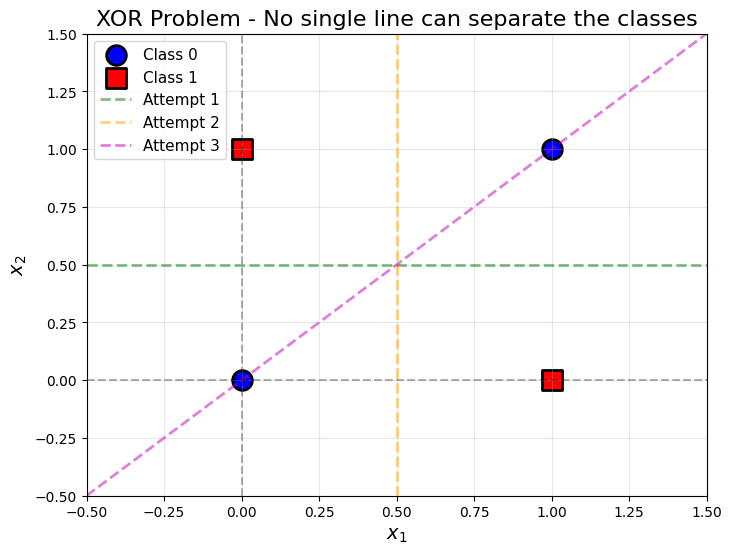

In [8]:
plt.figure(figsize=(8, 6))

# Plot XOR data points
colors = ['blue', 'red', 'red', 'blue']
markers = ['o', 's', 's', 'o']
labels_shown = {0: False, 1: False}

for i, (x, y_true) in enumerate(zip(X_xor, y_xor)):
    label = f'Class {y_true}' if not labels_shown[y_true] else ''
    plt.scatter(x[0], x[1], c=colors[i], s=200, marker=markers[i],
               label=label, edgecolors='k', linewidth=2)
    labels_shown[y_true] = True

# Try to draw some potential decision boundaries (all fail)
x1_vals = np.linspace(-0.5, 1.5, 100)

# Attempt 1: Horizontal line
plt.plot(x1_vals, [0.5]*len(x1_vals), 'g--', linewidth=2, alpha=0.5, label='Attempt 1')

# Attempt 2: Vertical line
plt.axvline(0.5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Attempt 2')

# Attempt 3: Diagonal line
x2_diagonal = x1_vals
plt.plot(x1_vals, x2_diagonal, 'm--', linewidth=2, alpha=0.5, label='Attempt 3')

plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.title('XOR Problem - No single line can separate the classes', fontsize=16)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.show()

**La verdad geométrica**: Los puntos de la clase 0 (azules) están en esquinas **diagonalmente opuestas**, y los de la clase 1 (rojos) también. **No existe ninguna línea recta** que pueda separar estas dos clases.

Este problema no es linealmente separable. Y aquí está la limitación fundamental del perceptrón: solo puede aprender patrones linealmente separables.

### Solución: múltiples perceptrones trabajando juntos

La clave está en combinar varios perceptrones. La idea es brillante:

1. **Primera capa**: Usamos varios perceptrones en paralelo, cada uno creando su propia frontera de decisión lineal
2. **Segunda capa**: Un perceptrón final combina las salidas de la primera capa

Cada perceptrón de la primera capa transforma el espacio de entrada, y el perceptrón de salida trabaja sobre este **espacio transformado** donde el problema puede volverse linealmente separable.

### Arquitectura de dos capas para resolver XOR

Podemos descomponer XOR como una combinación de operaciones más simples:

$$
\text{XOR}(x_1, x_2) = \text{AND}(\text{OR}(x_1, x_2), \text{NAND}(x_1, x_2))
$$

Donde NAND (NOT AND) es la negación de AND. Implementemos esta arquitectura:

In [9]:
class TwoLayerPerceptron:
    def __init__(self):
        """
        Two-layer perceptron network to solve XOR.
        Architecture: 2 inputs -> 2 hidden neurons -> 1 output
        """
        # Hidden layer: two perceptrons
        self.hidden1 = PerceptronWithLearning(n_inputs=2)
        self.hidden2 = PerceptronWithLearning(n_inputs=2)

        # Output layer: one perceptron
        self.output = PerceptronWithLearning(n_inputs=2)

        # Manually set weights for XOR solution
        # Hidden neuron 1: OR-like behavior
        self.hidden1.weights = np.array([1.0, 1.0])
        self.hidden1.bias = -0.5

        # Hidden neuron 2: NAND-like behavior
        self.hidden2.weights = np.array([-1.0, -1.0])
        self.hidden2.bias = 1.5

        # Output neuron: AND-like behavior
        self.output.weights = np.array([1.0, 1.0])
        self.output.bias = -1.5

    def predict(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input array [x1, x2]

        Returns:
            Final prediction (0 or 1)
        """
        # Hidden layer activations
        h1 = self.hidden1.predict(x)
        h2 = self.hidden2.predict(x)

        # Output layer activation
        hidden_output = np.array([h1, h2])
        return self.output.predict(hidden_output)

# Test the two-layer network on XOR
network = TwoLayerPerceptron()

print("Two-Layer Perceptron - XOR Solution:")
print("-" * 50)
for x, y_true in zip(X_xor, y_xor):
    y_pred = network.predict(x)

    # Show intermediate activations
    h1 = network.hidden1.predict(x)
    h2 = network.hidden2.predict(x)

    status = "✓" if y_pred == y_true else "✗"
    print(f"Input: {x} | Hidden: [{h1}, {h2}] | Output: {y_pred} | True: {y_true} {status}")

Two-Layer Perceptron - XOR Solution:
--------------------------------------------------
Input: [0 0] | Hidden: [0, 1] | Output: 0 | True: 0 ✓
Input: [0 1] | Hidden: [1, 1] | Output: 1 | True: 1 ✓
Input: [1 0] | Hidden: [1, 1] | Output: 1 | True: 1 ✓
Input: [1 1] | Hidden: [1, 0] | Output: 0 | True: 0 ✓


### De rectas a regiones poligonales: el poder de la composición

Visualicemos cómo la red de dos capas resuelve XOR:

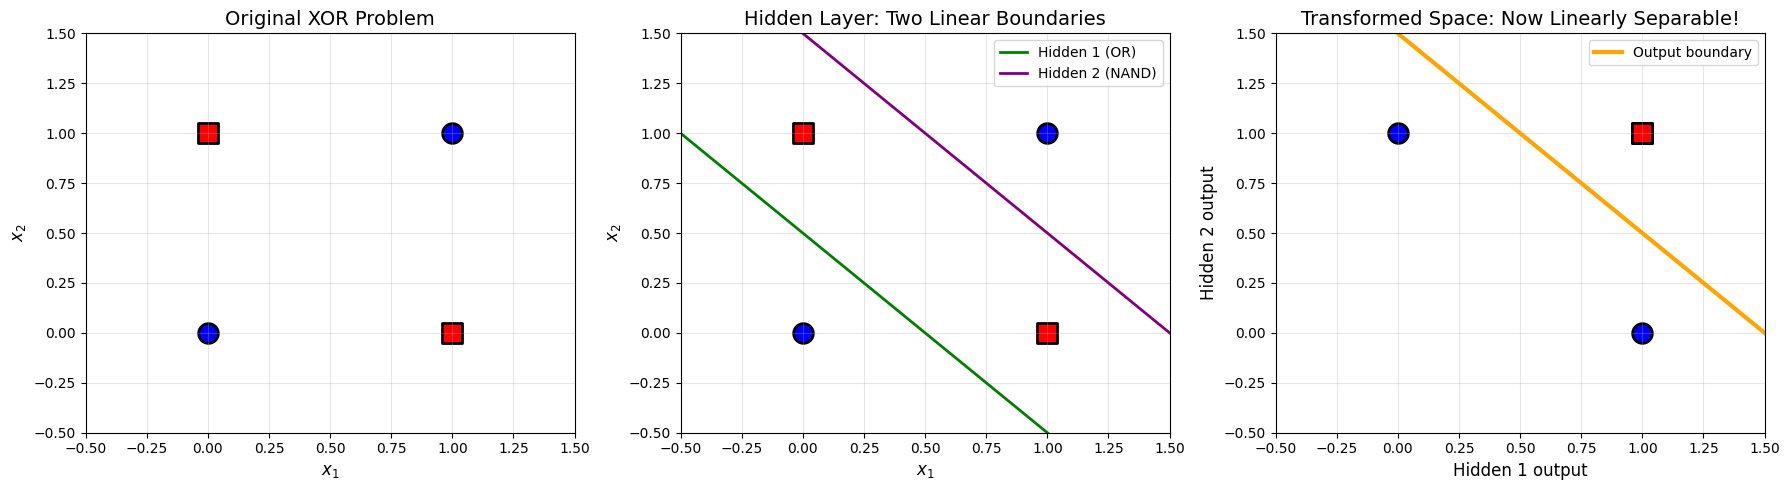

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original XOR problem
ax1 = axes[0]
for i, (x, y_true) in enumerate(zip(X_xor, y_xor)):
    color = 'blue' if y_true == 0 else 'red'
    marker = 'o' if y_true == 0 else 's'
    ax1.scatter(x[0], x[1], c=color, s=200, marker=marker,
               edgecolors='k', linewidth=2)

ax1.set_xlabel('$x_1$', fontsize=12)
ax1.set_ylabel('$x_2$', fontsize=12)
ax1.set_title('Original XOR Problem', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 1.5)
ax1.set_ylim(-0.5, 1.5)

# Hidden layer decisions
ax2 = axes[1]
x1_range = np.linspace(-0.5, 1.5, 100)

# Decision boundary for hidden neuron 1 (OR-like)
x2_h1 = -(network.hidden1.weights[0] * x1_range + network.hidden1.bias) / network.hidden1.weights[1]
ax2.plot(x1_range, x2_h1, 'g-', linewidth=2, label='Hidden 1 (OR)')

# Decision boundary for hidden neuron 2 (NAND-like)
x2_h2 = -(network.hidden2.weights[0] * x1_range + network.hidden2.bias) / network.hidden2.weights[1]
ax2.plot(x1_range, x2_h2, 'purple', linewidth=2, label='Hidden 2 (NAND)')

for i, (x, y_true) in enumerate(zip(X_xor, y_xor)):
    color = 'blue' if y_true == 0 else 'red'
    marker = 'o' if y_true == 0 else 's'
    ax2.scatter(x[0], x[1], c=color, s=200, marker=marker,
               edgecolors='k', linewidth=2)

ax2.set_xlabel('$x_1$', fontsize=12)
ax2.set_ylabel('$x_2$', fontsize=12)
ax2.set_title('Hidden Layer: Two Linear Boundaries', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-0.5, 1.5)

# Transformed space (hidden layer outputs)
ax3 = axes[2]
hidden_outputs = []
for x in X_xor:
    h1 = network.hidden1.predict(x)
    h2 = network.hidden2.predict(x)
    hidden_outputs.append([h1, h2])

hidden_outputs = np.array(hidden_outputs)

for i, (h, y_true) in enumerate(zip(hidden_outputs, y_xor)):
    color = 'blue' if y_true == 0 else 'red'
    marker = 'o' if y_true == 0 else 's'
    ax3.scatter(h[0], h[1], c=color, s=200, marker=marker,
               edgecolors='k', linewidth=2)

# Output layer decision boundary in transformed space
h1_vals = np.linspace(-0.5, 1.5, 100)
h2_vals = -(network.output.weights[0] * h1_vals + network.output.bias) / network.output.weights[1]
ax3.plot(h1_vals, h2_vals, 'orange', linewidth=3, label='Output boundary')

ax3.set_xlabel('Hidden 1 output', fontsize=12)
ax3.set_ylabel('Hidden 2 output', fontsize=12)
ax3.set_title('Transformed Space: Now Linearly Separable!', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(-0.5, 1.5)
ax3.set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

**La magia de la composición**:
- La **primera capa** crea dos fronteras lineales que dividen el espacio de entrada
- Estas dos rectas, combinadas, crean una **región poligonal** (en este caso, una región en forma de L)
- En el **espacio transformado** (las salidas de la capa oculta), el problema XOR se vuelve linealmente separable
- La **segunda capa** simplemente traza una línea en este nuevo espacio

### El nacimiento conceptual del perceptrón multicapa (MLP)

Este descubrimiento fue revolucionario. Lo que aprendimos:

1. **Una sola neurona es limitada**: Solo puede separar con líneas rectas (o hiperplanos)

2. **Múltiples neuronas crean complejidad**: Al combinar varias neuronas en capas:
   - Cada neurona de la primera capa crea una frontera lineal
   - La composición de estas fronteras genera regiones más complejas
   - Con suficientes neuronas y capas, podemos aproximar cualquier función

3. **La transformación es la clave**: Las capas ocultas transforman el espacio de entrada en representaciones donde los problemas se vuelven más sencillos de resolver

4. **Profundidad sobre amplitud**: A veces, añadir más capas es más efectivo que añadir más neuronas a una sola capa

Este es el **perceptrón multicapa (MLP)**: la arquitectura fundacional de las redes neuronales modernas. Aunque hoy usamos funciones de activación más sofisticadas (ReLU, sigmoid, tanh) y algoritmos de entrenamiento más avanzados (backpropagation, optimizadores como Adam), el principio fundamental permanece intacto.

**Del XOR al Deep Learning**: El problema XOR nos enseñó que la verdadera potencia no está en hacer neuronas más complejas, sino en **conectar neuronas simples en arquitecturas profundas**. Esta intuición, desarrollada en los años 60 y redescubierta en los 80, es la base del aprendizaje profundo moderno.

## Sección 5: Conclusiones

Hemos recorrido un viaje fascinante desde una simple neurona artificial hasta las redes neuronales multicapa. Es momento de reflexionar sobre las lecciones fundamentales que el perceptrón nos enseña.

### El perceptrón es elegante en su simplicidad pero limitado en soledad

El perceptrón de Rosenblatt encapsula una idea poderosa en una fórmula matemática minimal:

$$
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
$$

Esta simplicidad es tanto su belleza como su limitación. Un perceptrón individual puede:
- ✓ Aprender de datos mediante ajuste automático de pesos
- ✓ Resolver cualquier problema linealmente separable
- ✓ Converger a una solución en tiempo finito (teorema de convergencia del perceptrón)

Pero no puede:
- ✗ Resolver problemas no linealmente separables como XOR
- ✗ Capturar relaciones complejas entre variables
- ✗ Aprender representaciones jerárquicas de datos

La historia del perceptrón es también una historia de expectativas. En los años 60, hubo un entusiasmo desmedido sobre lo que una sola neurona podría lograr. El libro "Perceptrons" (1969) de Minsky y Papert demostró matemáticamente estas limitaciones, lo que paradójicamente causó un "invierno de la IA" que duró años.

### La potencia surge de la conexión entre unidades simples

La verdadera revelación llegó cuando entendimos que **la limitación no estaba en la neurona, sino en usarla aisladamente**. Al conectar múltiples perceptrones en capas:

- Cada neurona aporta una transformación simple (una frontera lineal)
- La composición de transformaciones simples crea transformaciones complejas
- Dos líneas rectas pueden definir una región poligonal
- Tres líneas pueden definir un triángulo
- Con suficientes neuronas y capas, podemos aproximar fronteras de decisión arbitrariamente complejas

Este principio de **composicionalidad** es fundamental no solo en redes neuronales, sino en toda la computación:
- Los transistores individuales son simples interruptores, pero billones de ellos forman procesadores potentes
- Las neuronas biológicas son procesadores básicos, pero 86 mil millones de ellas producen consciencia
- Las palabras individuales son limitadas, pero combinadas expresan ideas infinitas

### Puente histórico entre la lógica booleana y el aprendizaje profundo

El perceptrón ocupa un lugar único en la historia de la inteligencia artificial. Conecta tres mundos:

**1. La lógica booleana clásica** (años 1800s): Boole, De Morgan y otros crearon el álgebra de la lógica. Las compuertas AND, OR, XOR son manifestaciones de esta teoría.

**2. La neurociencia** (años 1940s): McCulloch y Pitts modelaron neuronas como unidades lógicas binarias, demostrando que redes de estas neuronas podían computar cualquier función lógica.

**3. El aprendizaje automático** (años 1950s-presente): Rosenblatt introdujo el **aprendizaje adaptativo**. Por primera vez, la máquina no estaba programada explícitamente—aprendía de ejemplos.

El perceptrón demostró que podíamos construir máquinas que:
- No requieren programación explícita de cada regla
- Mejoran automáticamente con la experiencia
- Generalizan a partir de ejemplos para enfrentar casos nuevos

Esta idea evolucionó hacia:
- Perceptrones multicapa (1980s) con backpropagation
- Redes neuronales convolucionales para visión (1990s-2000s)
- Redes neuronales profundas y transformers (2010s-2020s)

Pero la esencia permanece: **unidades simples de procesamiento, conectadas en capas, aprendiendo de datos**.

### Principio fundamental: a veces la complejidad emerge de lo simple

Quizás la lección más profunda del perceptrón trasciende la inteligencia artificial. Es una lección sobre la naturaleza de la complejidad misma:

**La complejidad no requiere componentes complejos—emerge de la organización de componentes simples.**

Este principio aparece en toda la naturaleza y la tecnología:
- **Física**: Átomos simples forman moléculas complejas
- **Biología**: Células simples forman organismos inteligentes  
- **Química**: Cuatro bases nucleotídicas (A, T, G, C) codifican toda la vida
- **Computación**: Operaciones binarias simples ejecutan cualquier algoritmo
- **Matemáticas**: Axiomas simples generan teoremas profundos

El perceptrón nos enseña que no necesitamos crear neuronas artificiales más "inteligentes". Necesitamos conectar neuronas simples de formas más sofisticadas. Esta intuición guía el diseño de arquitecturas modernas: ResNets, Transformers, GANs—todas son composiciones de operaciones fundamentalmente simples.

### Mensaje final

> **Lo que no puede hacer una neurona artificial, lo pueden hacer varias trabajando juntas, igual que en nuestro cerebro.**

Esta frase resume décadas de investigación. Una sola neurona biológica puede distinguir patrones simples. Pero 86 mil millones de neuronas, organizadas en la corteza cerebral con sus seis capas, sus conexiones recurrentes y sus bucles de retroalimentación, producen pensamiento, creatividad, empatía y autoconsciencia.

De manera similar, un perceptrón simple puede trazar una línea. Pero miles de perceptrones en docenas de capas pueden:
- Reconocer rostros en fotografías
- Traducir entre idiomas
- Generar arte original
- Jugar ajedrez a nivel sobrehumano
- Diagnosticar enfermedades en imágenes médicas

El perceptrón de 1957, con su sala llena de cables y su capacidad para reconocer formas básicas, parecía primitivo incluso en su época. Pero contenía una semilla conceptual que germinaría en el aprendizaje profundo moderno.

Cuando uses redes neuronales complejas—cuando entrenes un modelo de lenguaje, cuando ajustes una CNN, cuando implementes un transformer—recuerda: todo comenzó con una pregunta simple: **¿Podemos hacer que una máquina aprenda imitando a una neurona?**

La respuesta de Rosenblatt fue: Sí. Una neurona a la vez. Una capa a la vez. Un ejemplo a la vez.

Y esa respuesta cambió el mundo.

---

### Para explorar más

Si este artículo despertó tu curiosidad, aquí hay algunos caminos para continuar:

1. **Implementa backpropagation**: El algoritmo que permite entrenar redes multicapa eficientemente
2. **Experimenta con funciones de activación**: ReLU, sigmoid, tanh—cada una tiene propiedades únicas
3. **Explora arquitecturas modernas**: CNNs para imágenes, RNNs para secuencias, Transformers para lenguaje
4. **Lee los clásicos**: "Perceptrons" de Minsky y Papert, "Parallel Distributed Processing" de Rumelhart

El perceptrón fue solo el comienzo. El viaje continúa.
